In [1]:
import json, time, copy, os, shutil
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    roc_curve, precision_recall_curve
)

# ---- All CPU threads ----
n_threads = os.cpu_count() or 4
torch.set_num_threads(n_threads)
print(f"Using {n_threads} CPU threads")

PROJECT_ROOT = Path(r"C:\Users\Admin\lungprints")
RES_DIR      = PROJECT_ROOT / "results"
FIG_DIR      = RES_DIR / "figures"
MODEL_DIR    = RES_DIR / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)
DEVICE = torch.device("cpu")
print("Device:", DEVICE)

Using 8 CPU threads
Device: cpu


In [2]:
# Configurations
IMG_SIZE   = 96        # same as Notebook 03 fast mode
BATCH_SIZE = 64
EPOCHS     = 15
PATIENCE   = 4
LR         = 3e-4

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
print(f"Config: IMG={IMG_SIZE}, BATCH={BATCH_SIZE}, EPOCHS={EPOCHS}, LR={LR}")

Config: IMG=96, BATCH=64, EPOCHS=15, LR=0.0003


In [3]:
# load splits and build loaders
with open(RES_DIR / "splits.json") as f:
    S = json.load(f)

train_files, train_labels = S["train_files"], S["train_labels"]
val_files,   val_labels   = S["val_files"],   S["val_labels"]
test_files,  test_labels  = S["test_files"],  S["test_labels"]
class_weights = torch.tensor(S["class_weights"], dtype=torch.float32)

train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomRotation(8),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.95, 1.05)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
eval_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class ChestXrayDataset(Dataset):
    def __init__(self, files, labels, transform=None):
        self.files = list(files); self.labels = list(labels); self.transform = transform
    def __len__(self): return len(self.files)
    def __getitem__(self, idx):
        img = Image.open(self.files[idx]).convert("L")
        if self.transform: img = self.transform(img)
        return img, self.labels[idx]

train_loader = DataLoader(ChestXrayDataset(train_files, train_labels, train_tfms),
                          batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader   = DataLoader(ChestXrayDataset(val_files, val_labels, eval_tfms),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(ChestXrayDataset(test_files, test_labels, eval_tfms),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Batches — train {len(train_loader)}, val {len(val_loader)}, test {len(test_loader)}")

Batches — train 66, val 17, test 10


In [4]:
# shared utilities
def compute_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "accuracy":  accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall":    recall_score(y_true, y_pred, zero_division=0),
        "f1":        f1_score(y_true, y_pred, zero_division=0),
        "roc_auc":   roc_auc_score(y_true, y_prob),
        "pr_auc":    average_precision_score(y_true, y_prob),
    }

def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss = 0.0
    all_probs, all_labels = [], []
    with torch.set_grad_enabled(is_train):
        for imgs, lbls in loader:
            logits = model(imgs)
            loss = criterion(logits, lbls)
            if is_train:
                optimizer.zero_grad(); loss.backward(); optimizer.step()
            total_loss += loss.item() * imgs.size(0)
            probs = F.softmax(logits, dim=1)[:, 1].detach().numpy()
            all_probs.extend(probs.tolist()); all_labels.extend(lbls.numpy().tolist())
    return total_loss / len(loader.dataset), compute_metrics(np.array(all_labels), np.array(all_probs))

In [ ]:
# generic training function
def train_model(model, name, epochs=EPOCHS, patience=PATIENCE, lr=LR):
    print(f"\n{'='*60}\nTraining: {name}\n{'='*60}")
    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=class_weights.to(DEVICE))
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=1e-4
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=2
    )

    best_f1, best_state, best_metrics, best_epoch = 0.0, None, None, 0
    no_improve = 0
    history = {k: [] for k in [
        "train_loss","val_loss","train_f1","val_f1",
        "train_recall","val_recall","train_roc_auc","val_roc_auc",
        "train_pr_auc","val_pr_auc"
    ]}

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr_loss, tr_m = run_epoch(model, train_loader, criterion, optimizer)
        va_loss, va_m = run_epoch(model, val_loader, criterion, None)
        scheduler.step(va_m["f1"])
        dt = time.time() - t0

        history["train_loss"].append(tr_loss); history["val_loss"].append(va_loss)
        history["train_f1"].append(tr_m["f1"]); history["val_f1"].append(va_m["f1"])
        history["train_recall"].append(tr_m["recall"]); history["val_recall"].append(va_m["recall"])
        history["train_roc_auc"].append(tr_m["roc_auc"]); history["val_roc_auc"].append(va_m["roc_auc"])
        history["train_pr_auc"].append(tr_m["pr_auc"]); history["val_pr_auc"].append(va_m["pr_auc"])

        print(f"Epoch {epoch:02d}/{epochs} ({dt:.0f}s) | "
              f"train f1 {tr_m['f1']:.3f} rec {tr_m['recall']:.3f} | "
              f"val f1 {va_m['f1']:.3f} rec {va_m['recall']:.3f} auc {va_m['roc_auc']:.3f}")

        if va_m["f1"] > best_f1:
            best_f1, best_epoch, best_metrics = va_m["f1"], epoch, va_m
            best_state = copy.deepcopy(model.state_dict())
            torch.save({"model_state": best_state, "epoch": epoch,
                        "val_metrics": va_m, "history": history,
                        "name": name, "img_size": IMG_SIZE},
                       MODEL_DIR / f"{name}_best.pt")
            no_improve = 0
            print(f"  → new best (val F1 = {best_f1:.4f})")
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"Early stopping at epoch {epoch}."); break

       # Gap analysis (printed for the report)
    tr_f1 = history["train_f1"]; va_f1 = history["val_f1"]
    i = int(np.argmax(va_f1))
    gap = tr_f1[i] - va_f1[i]
    if gap > 0.05:
        diag = "OVERFITTING"
    elif tr_f1[i] < 0.80 and va_f1[i] < 0.80:
        diag = "UNDERFITTING"
    elif abs(gap) <= 0.03:
        diag = "WELL-FITTED"
    else:
        diag = "MILD OVERFITTING"
    print(f"\n--- {name} gap ---")
    print(f"  best epoch {i+1} | train F1 {tr_f1[i]:.4f} | val F1 {va_f1[i]:.4f} | gap {gap:+.4f} -> {diag}")

    return {"name": name, "best_epoch": best_epoch, "best_f1": best_f1,
            "val_metrics": best_metrics, "history": history,
            "gap": float(gap), "diagnosis": diag}

In [6]:
# build function (freeze backbone, fine tune last block)
def build_densenet121():
    m = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
    for p in m.parameters():
        p.requires_grad = False
    for p in m.features.denseblock4.parameters():
        p.requires_grad = True
    for p in m.features.norm5.parameters():
        p.requires_grad = True
    m.classifier = nn.Linear(m.classifier.in_features, 2)
    return m

def build_resnet50():
    m = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
    for p in m.parameters():
        p.requires_grad = False
    for p in m.layer4.parameters():
        p.requires_grad = True
    m.fc = nn.Linear(m.fc.in_features, 2)
    return m

def build_efficientnet_b0():
    m = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
    for p in m.parameters():
        p.requires_grad = False
    for p in m.features[-1].parameters():
        p.requires_grad = True
    in_features = m.classifier[-1].in_features
    m.classifier[-1] = nn.Linear(in_features, 2)
    return m

In [7]:
# train DenseNet121
densenet_result = train_model(build_densenet121(), "densenet121")

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to C:\Users\Admin/.cache\torch\hub\checkpoints\densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:18<00:00, 1.71MB/s]



Training: densenet121
Epoch 01/15 (359s) | train f1 0.944 rec 0.917 | val f1 0.961 rec 0.932 auc 0.993
  → new best (val F1 = 0.9615)
Epoch 02/15 (310s) | train f1 0.969 rec 0.955 | val f1 0.948 rec 0.905 auc 0.994
Epoch 03/15 (371s) | train f1 0.970 rec 0.955 | val f1 0.964 rec 0.936 auc 0.995
  → new best (val F1 = 0.9642)
Epoch 04/15 (482s) | train f1 0.974 rec 0.962 | val f1 0.970 rec 0.949 auc 0.996
  → new best (val F1 = 0.9704)
Epoch 05/15 (501s) | train f1 0.979 rec 0.971 | val f1 0.972 rec 0.950 auc 0.997
  → new best (val F1 = 0.9723)
Epoch 06/15 (500s) | train f1 0.980 rec 0.969 | val f1 0.971 rec 0.949 auc 0.997
Epoch 07/15 (498s) | train f1 0.977 rec 0.966 | val f1 0.976 rec 0.956 auc 0.997
  → new best (val F1 = 0.9763)
Epoch 08/15 (495s) | train f1 0.975 rec 0.961 | val f1 0.970 rec 0.945 auc 0.997
Epoch 09/15 (673s) | train f1 0.983 rec 0.974 | val f1 0.969 rec 0.945 auc 0.997
Epoch 10/15 (500s) | train f1 0.985 rec 0.978 | val f1 0.961 rec 0.928 auc 0.997
Epoch 11/15 

In [8]:
# train EfficientNet-B0
efficientnet_result = train_model(build_efficientnet_b0(), "efficientnetb0")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\Admin/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:12<00:00, 1.72MB/s]



Training: efficientnetb0
Epoch 01/15 (153s) | train f1 0.869 rec 0.796 | val f1 0.798 rec 0.671 auc 0.960
  → new best (val F1 = 0.7979)
Epoch 02/15 (153s) | train f1 0.922 rec 0.880 | val f1 0.861 rec 0.763 auc 0.971
  → new best (val F1 = 0.8613)
Epoch 03/15 (157s) | train f1 0.935 rec 0.898 | val f1 0.877 rec 0.788 auc 0.974
  → new best (val F1 = 0.8768)
Epoch 04/15 (159s) | train f1 0.939 rec 0.907 | val f1 0.899 rec 0.826 auc 0.974
  → new best (val F1 = 0.8992)
Epoch 05/15 (168s) | train f1 0.941 rec 0.910 | val f1 0.903 rec 0.830 auc 0.976
  → new best (val F1 = 0.9034)
Epoch 06/15 (157s) | train f1 0.945 rec 0.916 | val f1 0.900 rec 0.826 auc 0.978
Epoch 07/15 (162s) | train f1 0.949 rec 0.922 | val f1 0.893 rec 0.812 auc 0.979
Epoch 08/15 (165s) | train f1 0.948 rec 0.925 | val f1 0.888 rec 0.804 auc 0.979
Epoch 09/15 (196s) | train f1 0.945 rec 0.920 | val f1 0.916 rec 0.852 auc 0.981
  → new best (val F1 = 0.9156)
Epoch 10/15 (206s) | train f1 0.948 rec 0.922 | val f1 0.91

In [10]:
# Build comparison table
rows = []

# Baseline from Notebook 03, if available
baseline_path = RES_DIR / "baseline_cnn_results.json"
if baseline_path.exists():
    with open(baseline_path) as f:
        b = json.load(f)
    m = b["val_metrics"]
    rows.append({
        "model": "baseline_cnn", "best_epoch": b["best_epoch"],
        "accuracy": m["accuracy"], "precision": m["precision"],
        "recall": m["recall"], "f1": m["f1"],
        "roc_auc": m["roc_auc"], "pr_auc": m["pr_auc"],
    })

for r in [densenet_result, efficientnet_result]:
    m = r["val_metrics"]
    rows.append({
        "model": r["name"], "best_epoch": r["best_epoch"],
        "accuracy": m["accuracy"], "precision": m["precision"],
        "recall": m["recall"], "f1": m["f1"],
        "roc_auc": m["roc_auc"], "pr_auc": m["pr_auc"],
    })

df = pd.DataFrame(rows).sort_values("f1", ascending=False).reset_index(drop=True)
df_disp = df.copy()
for c in ["accuracy","precision","recall","f1","roc_auc","pr_auc"]:
    df_disp[c] = df_disp[c].round(4)

print(df_disp.to_string(index=False))
df.to_csv(RES_DIR / "04_model_comparison.csv", index=False)
print("\nSaved:", RES_DIR / "04_model_comparison.csv")

         model  best_epoch  accuracy  precision  recall     f1  roc_auc  pr_auc
   densenet121          11    0.9771     0.9922  0.9768 0.9844   0.9972  0.9990
  baseline_cnn          10    0.9742     0.9896  0.9755 0.9825   0.9944  0.9981
efficientnetb0          14    0.8902     0.9882  0.8623 0.9210   0.9808  0.9930

Saved: C:\Users\Admin\lungprints\results\04_model_comparison.csv


In [ ]:
# hyperparameter log
param_log = """
HYPERPARAMETER CHOICES — TRANSFER LEARNING MODELS

1. Learning rate:  3e-4
   Reason: stable fine-tuning for pretrained backbones.

2. Scheduler:  ReduceLROnPlateau(factor=0.5, patience=2)

3. Input resolution:  96x96 (CPU-friendly)

4. Batch size:  64

5. Transfer strategy:  freeze backbone, unfreeze last block only
   Reason: prevents catastrophic forgetting on small dataset while allowing
   domain adaptation to X-rays.

6. Loss:  CrossEntropyLoss(weight=class_weights)
   Reason: ~1:3 class imbalance; weighted loss preserves recall on NORMAL.

7. Early stopping:  patience=4 epochs on val F1.
"""
print(param_log)
with open(RES_DIR / "04_hyperparameters.txt", "w") as f:
    f.write(param_log)
print("Saved:", RES_DIR / "04_hyperparameters.txt")

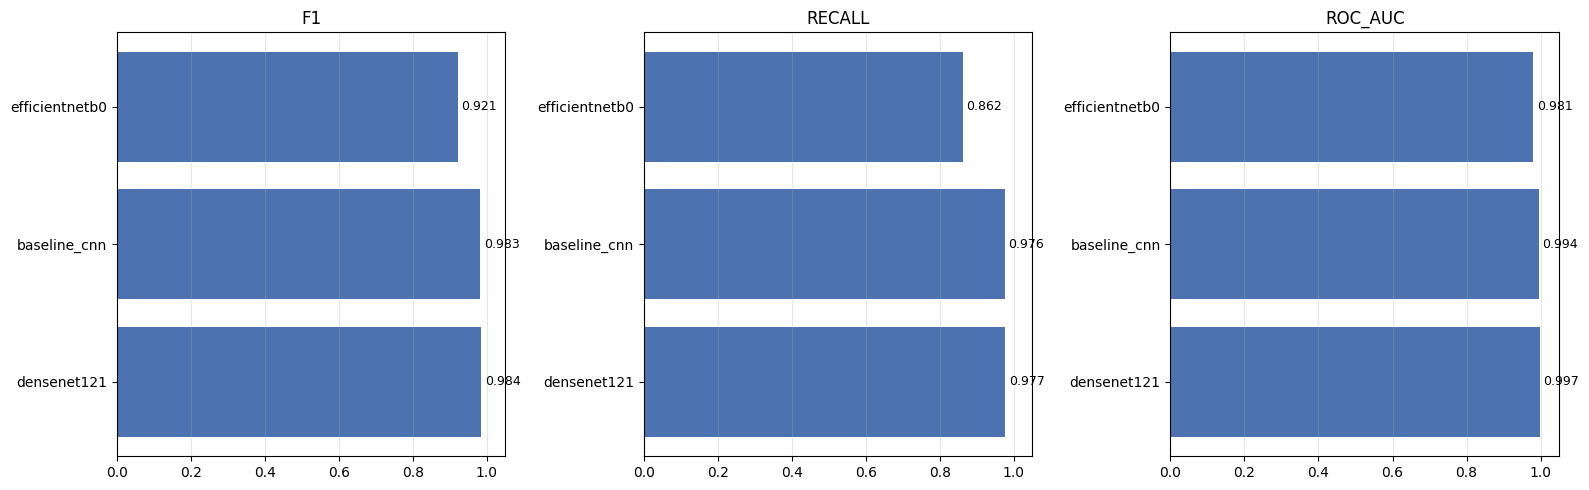

In [11]:
# comparison bar chart
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, metric in zip(axes, ["f1", "recall", "roc_auc"]):
    ax.barh(df["model"], df[metric], color="#4C72B0")
    ax.set_title(metric.upper()); ax.set_xlim(0, 1.05)
    for i, v in enumerate(df[metric]):
        ax.text(v + 0.01, i, f"{v:.3f}", va="center", fontsize=9)
    ax.grid(alpha=0.3, axis="x")
plt.tight_layout()
plt.savefig(FIG_DIR / "04_model_comparison.png", dpi=150)
plt.show()

In [12]:
# best model
best_row  = df.iloc[0]
best_name = best_row["model"]
print(f"Best model: {best_name} (val F1 = {best_row['f1']:.4f})")

best_src = MODEL_DIR / f"{best_name}_best.pt"
best_dst = MODEL_DIR / "best_model.pt"
shutil.copy(best_src, best_dst)
print("Copied to:", best_dst)

Best model: densenet121 (val F1 = 0.9844)
Copied to: C:\Users\Admin\lungprints\results\models\best_model.pt


In [13]:
# rebuild the best model and evaluate on validation
def build_model_by_name(name):
    if name == "baseline_cnn":
        class BaselineCNN(nn.Module):
            def __init__(self, num_classes=2):
                super().__init__()
                def block(in_c, out_c):
                    return nn.Sequential(
                        nn.Conv2d(in_c, out_c, 3, padding=1, bias=False),
                        nn.BatchNorm2d(out_c), nn.ReLU(inplace=True),
                        nn.MaxPool2d(2),
                    )
                self.features = nn.Sequential(block(3,32), block(32,64),
                                              block(64,128), block(128,128))
                self.pool = nn.AdaptiveAvgPool2d(1)
                self.classifier = nn.Sequential(
                    nn.Flatten(), nn.Dropout(0.4),
                    nn.Linear(128,64), nn.ReLU(inplace=True),
                    nn.Dropout(0.3), nn.Linear(64, num_classes))
            def forward(self, x):
                return self.classifier(self.pool(self.features(x)))
        return BaselineCNN()
    if name == "densenet121":    return build_densenet121()
    if name == "resnet50":       return build_resnet50()
    if name == "efficientnetb0": return build_efficientnet_b0()
    raise ValueError(name)

best_model = build_model_by_name(best_name).to(DEVICE)
ckpt = torch.load(best_dst, map_location=DEVICE)
best_model.load_state_dict(ckpt["model_state"])
print("Loaded best from epoch", ckpt["epoch"])

criterion = nn.CrossEntropyLoss(weight=class_weights.to(DEVICE))
_, va_m = run_epoch(best_model, val_loader, criterion, None)
print("\nValidation metrics of best model:")
for k, v in va_m.items():
    print(f"  {k:10s}: {v:.4f}")

Loaded best from epoch 11

Validation metrics of best model:
  accuracy  : 0.9771
  precision : 0.9922
  recall    : 0.9768
  f1        : 0.9844
  roc_auc   : 0.9972
  pr_auc    : 0.9990


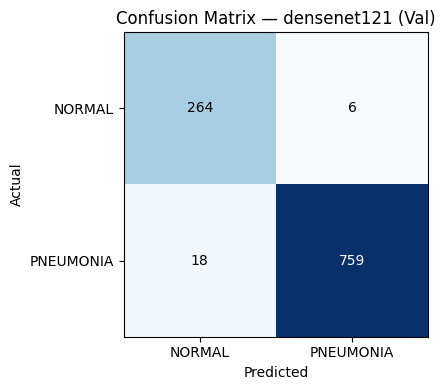

In [14]:
# confusion matrix
best_model.eval()
all_probs, all_labels = [], []
with torch.no_grad():
    for imgs, lbls in val_loader:
        probs = F.softmax(best_model(imgs), dim=1)[:, 1].numpy()
        all_probs.extend(probs.tolist()); all_labels.extend(lbls.numpy().tolist())

y_true = np.array(all_labels); y_prob = np.array(all_probs)
cm = confusion_matrix(y_true, (y_prob >= 0.5).astype(int))

fig, ax = plt.subplots(figsize=(5, 4))
ax.imshow(cm, cmap="Blues")
ax.set_xticks([0,1]); ax.set_xticklabels(["NORMAL","PNEUMONIA"])
ax.set_yticks([0,1]); ax.set_yticklabels(["NORMAL","PNEUMONIA"])
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i,j], ha="center", va="center",
                color="white" if cm[i,j] > cm.max()/2 else "black")
ax.set_title(f"Confusion Matrix — {best_name} (Val)")
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout()
plt.savefig(FIG_DIR / "04_best_confusion_matrix.png", dpi=150)
plt.show()

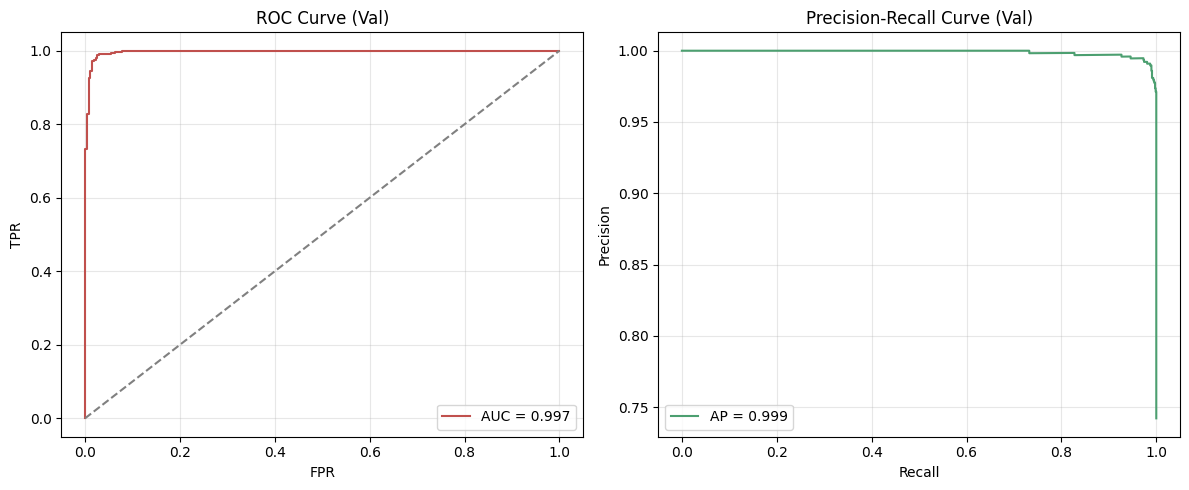

In [15]:
# roc and pr curves
fpr, tpr, _ = roc_curve(y_true, y_prob)
prec, rec, _ = precision_recall_curve(y_true, y_prob)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(fpr, tpr, label=f"AUC = {va_m['roc_auc']:.3f}", color="#C0504D")
axes[0].plot([0,1],[0,1],"--", color="gray")
axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR")
axes[0].set_title("ROC Curve (Val)"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(rec, prec, label=f"AP = {va_m['pr_auc']:.3f}", color="#4C9F70")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve (Val)"); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "04_best_roc_pr.png", dpi=150)
plt.show()

In [16]:
# final decision ( save)
final = {
    "best_model": best_name,
    "val_metrics": va_m,
    "confusion_matrix": cm.tolist(),
    "comparison_table": df.to_dict(orient="records"),
    "img_size": IMG_SIZE,
}
with open(RES_DIR / "04_best_model_selection.json", "w") as f:
    json.dump(final, f, indent=2)
print("Saved:", RES_DIR / "04_best_model_selection.json")

Saved: C:\Users\Admin\lungprints\results\04_best_model_selection.json
